In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
branch = pd.read_csv(r"C:\Users\kunal\OneDrive\Desktop\Banking\data\Dim_Branch.csv")
customer = pd.read_csv(r"C:\Users\kunal\OneDrive\Desktop\Banking\data\Dim_Customer.csv")
date = pd.read_csv(r"C:\Users\kunal\OneDrive\Desktop\Banking\data\Dim_Date.csv")
emp = pd.read_csv(r"C:\Users\kunal\OneDrive\Desktop\Banking\data\Dim_Employee.csv")
geo = pd.read_csv(r"C:\Users\kunal\OneDrive\Desktop\Banking\data\Dim_Geography.csv")
product = pd.read_csv(r"C:\Users\kunal\OneDrive\Desktop\Banking\data\Dim_Product.csv")


att = pd.read_csv(r"C:\Users\kunal\OneDrive\Desktop\Banking\data\Fact_Attrition.csv")
fact_per = pd.read_csv(r"C:\Users\kunal\OneDrive\Desktop\Banking\data\Fact_Branch_Performance.csv")

In [5]:
dataset = {
    'branch' : branch,
    'customer' : customer,
    'date':date,
    'emp':emp,
    'geo':geo,
    'product':product,
    'att':att,
    'fact_per':fact_per
}
for name,df in dataset.items():
    print(f"\n{name}")
    print(df.shape)
    print(df.info())
    print("**"*50)
    print(df.isnull().sum())
    print("**"*50)
    


branch
(20, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Branch_Key      20 non-null     int64 
 1   Branch_ID       20 non-null     object
 2   Branch_Name     20 non-null     object
 3   Region          20 non-null     object
 4   City            20 non-null     object
 5   State           20 non-null     object
 6   Branch_Type     20 non-null     object
 7   Opening_Date    20 non-null     object
 8   Branch_Manager  20 non-null     object
 9   Branch_Size     20 non-null     int64 
dtypes: int64(2), object(8)
memory usage: 1.7+ KB
None
****************************************************************************************************
Branch_Key        0
Branch_ID         0
Branch_Name       0
Region            0
City              0
State             0
Branch_Type       0
Opening_Date      0
Branch_Manager    0
Branch_Size     

In [6]:
customer.columns.tolist()

['Customer_Key',
 'Customer_ID',
 'Age',
 'Gender',
 'Occupation',
 'Income_Bracket',
 'Customer_Segment',
 'Account_Type',
 'Risk_Category',
 'Join_Date',
 'Credit_Score']

In [7]:
# Check missing values
customer.isnull().sum()

Customer_Key        0
Customer_ID         0
Age                 0
Gender              0
Occupation          0
Income_Bracket      0
Customer_Segment    0
Account_Type        0
Risk_Category       0
Join_Date           0
Credit_Score        0
dtype: int64

In [8]:
customer.duplicated().sum()

np.int64(0)

In [9]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_Key      2000 non-null   int64 
 1   Customer_ID       2000 non-null   object
 2   Age               2000 non-null   int64 
 3   Gender            2000 non-null   object
 4   Occupation        2000 non-null   object
 5   Income_Bracket    2000 non-null   object
 6   Customer_Segment  2000 non-null   object
 7   Account_Type      2000 non-null   object
 8   Risk_Category     2000 non-null   object
 9   Join_Date         2000 non-null   object
 10  Credit_Score      2000 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 172.0+ KB


In [10]:
customer.describe()

,Customer_Key,Age,Credit_Score
count,2000.000000,2000.000000,2000.000000
mean,1000.500000,44.799000,701.705000
std,577.494589,14.087471,85.105655
min,1.000000,22.000000,550.000000
25%,500.750000,32.000000,627.000000
50%,1000.500000,44.000000,702.000000
75%,1500.250000,57.000000,775.000000
max,2000.000000,69.000000,849.000000


In [11]:
att.columns


Index(['Attrition_ID', 'Customer_Key', 'Branch_Key', 'Date_Key',
       'Months_Inactive', 'Complaints_Count', 'Avg_Balance',
       'Transaction_Frequency', 'Loan_Default_Flag', 'Churn_Flag'],
      dtype='object')

In [12]:
corr_matrix = att[
    [
        'Months_Inactive',
        'Complaints_Count',
        'Avg_Balance',
        'Transaction_Frequency',
        'Loan_Default_Flag',
        'Churn_Flag'
    ]
].corr()

print(corr_matrix)

                       Months_Inactive  Complaints_Count  Avg_Balance  \
Months_Inactive               1.000000          0.015112     0.009841   
Complaints_Count              0.015112          1.000000     0.015406   
Avg_Balance                   0.009841          0.015406     1.000000   
Transaction_Frequency        -0.008209         -0.004110     0.010493   
Loan_Default_Flag            -0.001599         -0.004720     0.000624   
Churn_Flag                    0.275229          0.190115     0.021182   

                       Transaction_Frequency  Loan_Default_Flag  Churn_Flag  
Months_Inactive                    -0.008209          -0.001599    0.275229  
Complaints_Count                   -0.004110          -0.004720    0.190115  
Avg_Balance                         0.010493           0.000624    0.021182  
Transaction_Frequency               1.000000           0.018754   -0.004872  
Loan_Default_Flag                   0.018754           1.000000    0.111425  
Churn_Flag          

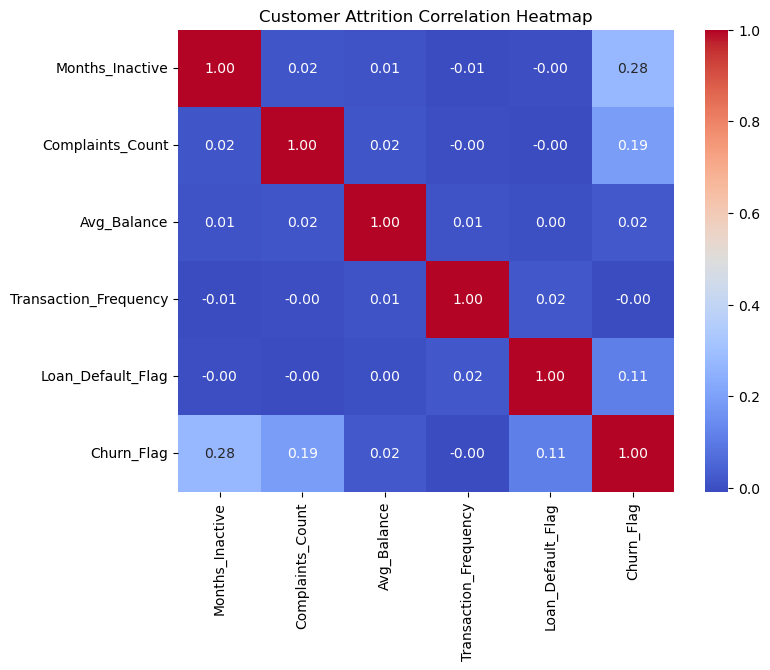

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Customer Attrition Correlation Heatmap')
plt.show()

In [14]:
from scipy.stats import pearsonr

features = [
    'Months_Inactive',
    'Complaints_Count',
    'Avg_Balance',
    'Transaction_Frequency',
    'Loan_Default_Flag'
]

for col in features:
    corr, p_value = pearsonr(att[col], att['Churn_Flag'])

    print(
        f"{col}: Correlation={corr:.3f}, "
        f"P-value={p_value:.5f}"
    )

Months_Inactive: Correlation=0.275, P-value=0.00000
Complaints_Count: Correlation=0.190, P-value=0.00000
Avg_Balance: Correlation=0.021, P-value=0.13425
Transaction_Frequency: Correlation=-0.005, P-value=0.73052
Loan_Default_Flag: Correlation=0.111, P-value=0.00000


In [15]:
def assign_segment(balance):
    if balance >= 100000:
        return 'Gold'
    elif balance >= 50000:
        return 'Silver'
    else:
        return 'Bronze'

att['Customer_Segment'] = att['Avg_Balance'].apply(assign_segment)

In [16]:
segment_counts = att['Customer_Segment'].value_counts()

print(segment_counts)

Customer_Segment
Gold      4457
Silver     278
Bronze     265
Name: count, dtype: int64


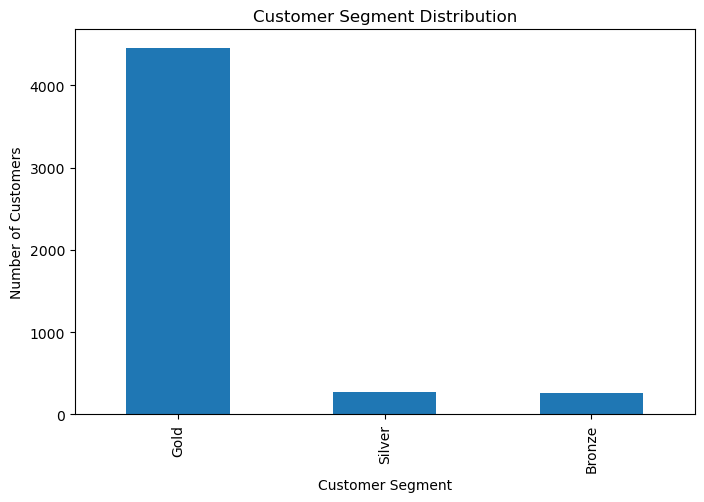

In [17]:
segment_counts = att['Customer_Segment'].value_counts()

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.show()

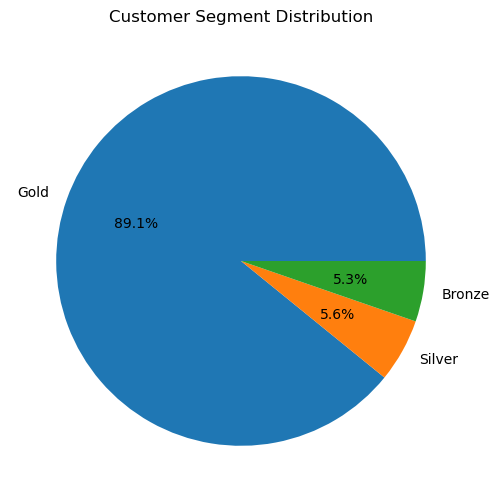

In [18]:
segment_counts = att['Customer_Segment'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Customer Segment Distribution')
plt.show()

In [19]:
att['Avg_Balance'].describe()

count      5000.000000
mean     496220.512250
std      290551.758351
min         787.520000
25%      243435.095000
50%      495485.420000
75%      753151.860000
max      999959.570000
Name: Avg_Balance, dtype: float64

In [20]:
fact_per.columns

Index(['Performance_ID', 'Date_Key', 'Branch_Key', 'Customer_Key',
       'Employee_Key', 'Product_Key', 'Transaction_Count',
       'Transaction_Amount', 'Customer_Attrition_Flag',
       'Employee_Customer_Ratio', 'Avg_Service_Time',
       'Customer_Satisfaction_Score', 'Revenue_Generated', 'Operating_Cost'],
      dtype='object')

In [21]:
fact_per['Employee_Productivity_Score'] = (
    fact_per['Revenue_Generated'] /
    fact_per['Operating_Cost']
)

In [22]:
fact_per[['Employee_Key',
          'Employee_Productivity_Score']] \
    .sort_values(
        by='Employee_Productivity_Score',
        ascending=False
    ).head(10)

,Employee_Key,Employee_Productivity_Score
3019,213,2.857103
8109,155,2.857029
6589,395,2.857018
6465,70,2.856523
8492,89,2.856482
13546,349,2.855863
10725,83,2.855124
9661,21,2.854746
4516,306,2.854657
5723,444,2.854507


In [23]:
fact_per.to_csv(
    'banking_powerbi_dataset.csv',
    index=False
)

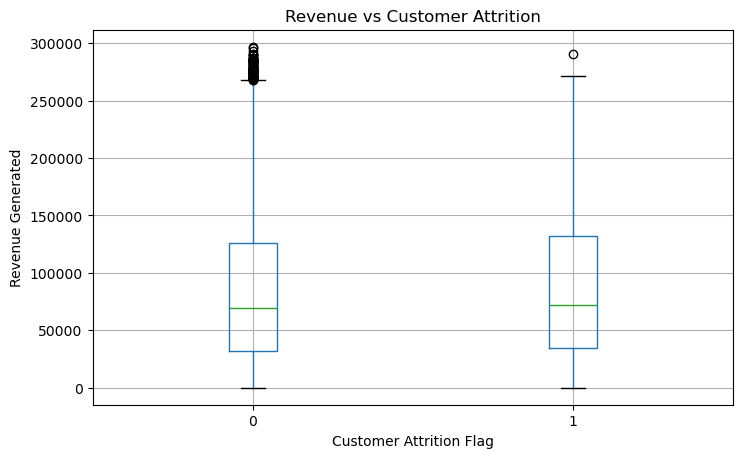

In [24]:
fact_per.boxplot(
    column='Revenue_Generated',
    by='Customer_Attrition_Flag',
    figsize=(8,5)
)

plt.title('Revenue vs Customer Attrition')
plt.suptitle('')
plt.xlabel('Customer Attrition Flag')
plt.ylabel('Revenue Generated')
plt.show()

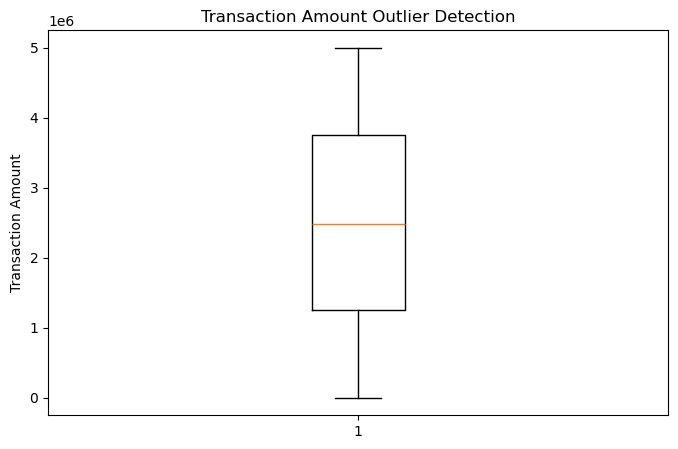

In [25]:
plt.figure(figsize=(8,5))
plt.boxplot(fact_per['Transaction_Amount'])
plt.title('Transaction Amount Outlier Detection')
plt.ylabel('Transaction Amount')
plt.show()

In [26]:
fact_per.to_csv(
    'banking_powerbi_dataset.csv',
    index=False
)

In [27]:
master = fact_per.merge( branch,on='Branch_Key',how='left')

master = master.merge(customer,on='Customer_Key',how='left')

master = master.merge(date,on='Date_Key',how='left')

master = master.merge(emp,on='Employee_Key',how='left')

master = master.merge(product,on='Product_Key',how='left')




In [29]:
master.to_csv("clean.csv",index = False)